# Day 3 — CNNs: Networks That Understand Pixels

CNNs don't just process pixels; they **understand** them.

On Day 1 we fed MNIST images into our network as a flat list of 784 numbers. That works for tiny
greyscale digits, but it throws away the most important property of an image: **pixels that are close
together are related**. A cat's ear is a *local pattern* — edges, curves, textures — and it's still a
cat's ear whether it appears in the top-left or bottom-right of the photo.

**Convolutional Neural Networks (CNNs)** are built around exactly these two ideas:

- **Local patterns**: small filters (kernels) slide across the image, each learning to detect one
  pattern — an edge, a colour blob, eventually eyes and wheels
- **Translation invariance**: the *same* filter is reused at every position, so a pattern is
  recognised wherever it appears (and we need far fewer parameters than a fully-connected layer)

Today you will:

1. Understand **convolution** and **pooling**, the two building blocks of CNNs
2. Build and train a CNN on **CIFAR-10** — real colour photos in 10 classes
3. Train it on real photos and **read its learning curves** (reusing Day 2's skills) to watch it overfit
4. Diagnose that overfitting and fix it with the **Day 2 toolbox**
5. **See inside** the network: visualize the feature maps it learns
6. Stand on the shoulders of giants with **transfer learning**
7. Survey how CNNs power **object detection** and **face recognition**

Our dataset gets an upgrade too: CIFAR-10 — 60,000 32×32 *colour* images (50,000 training images, 10,000 testing images), with 10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck

## CIFAR 10 Dataset

Downloading from the official source can be very slow (hours sometimes), despite the dataset being only ~170MB, so it may be a good idea to get it from an alternate source, like [Kaggle](https://www.kaggle.com/datasets/pankrzysiu/cifar10-python?select=cifar-10-python.tar.gz)

Using downloaded and verified file: ./data/cifar-10-python.tar.gz
Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


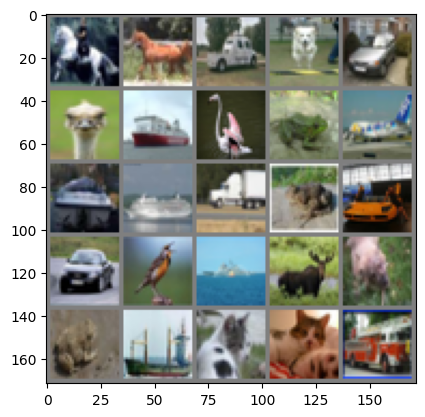

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Hyper-parameters 
num_epochs = 10
batch_size = 32
learning_rate = 0.001

# dataset has PILImage images of range [0, 1]. 
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(imgs):
    imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()

# one batch of random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
img_grid = torchvision.utils.make_grid(images[0:25], nrow=5)
imshow(img_grid)

# Kernel Convolution and MaxPooling
Kernel Convolution is a process that takes a kernel (usually square and of odd size) and slides it across an image to compute a new image (for blurring, edge detection etc) or feature map.

It's commonly used in Computer Vision to extract features from images. [In this notebook](https://github.com/samerhanze/Vision2026/blob/main/L2_Filters_and_Enhancement/Lecture_2_Lesson_Notebook.ipynb), I have some examples of such uses.

This process is not only for images, but can also be applied on 1D datasets (like time series). [This video](https://www.youtube.com/watch?v=KuXjwB4LzSA) explains the concept in more detail.

![conv](convolution.jpg)

The idea (for Deep Learning) is to create a network that can learn such filters on its own, rather than define them by hand, like we do for traditional computer vision.

In PyTorch, A convolution layer has the following parameters:

``` python
# basic convolution layer
conv_layer = nn.Conv2d(
    in_channels=3, # RGB images have 3 channels
    out_channels=6, # number of filters
    kernel_size=5, # kernel size of the filter (5x5)
    stride=1, # step size of the filter
    padding=0 # zero padding added to both sides of the input
)
```

Pooling is usually used in tandem with convolution as way to reduce the size of end result of each layer, which makes the computation fast, reduces memory and also prevents overfitting. Two common types of pooling layers are max pooling and average pooling.

![maxpool](maxpooling.png)

A typical Convolutional Neural Network consists of these types of layers, and ending with a fully connected/linear/dense layer to convert the end image into an output result (e.g. a class)

![cnn](cnn.png)

Let us build one such network

*To better understand how these figures are gotten, check out the layer by layer buildup example (`convolution_output_dimensions_test.ipynb`)in the extras folder*

You can also look at [this interactive visualisation](https://www.bulovic.at/cnn/) to see how a CNN propagates the input for digit recognition.

In [3]:
# Creating the Model
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 input image channel, 32 output channels, 3x3 square convolution
        self.conv1 = nn.Conv2d(3, 32, 3) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.fc1 = nn.Linear(64*4*4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # N, 3, 32, 32
        x = F.relu(self.conv1(x))   # -> N, 32, 30, 30 (because no padding, so 32-2=30)
        x = self.pool(x)            # -> N, 32, 15, 15 (because pooling halves the dimensions)
        x = F.relu(self.conv2(x))   # -> N, 64, 13, 13
        x = self.pool(x)            # -> N, 64, 6, 6 (rounded down from 6.5)
        x = F.relu(self.conv3(x))   # -> N, 64, 4, 4
        x = torch.flatten(x, 1)     # -> N, 1024
        x = F.relu(self.fc1(x))     # -> N, 64
        x = self.fc2(x)             # -> N, 10
        return x

### Why is `fc1` input `64*4*4`?

`64*4*4` is just the shape of the **last conv output, flattened**: **64 feature maps, each 4×4 pixels** → 64 × 4 × 4 = **1024** numbers. A `Linear` layer needs a flat vector, so we multiply the dimensions out.

Where do `64` and `4×4` come from? Two simple rules, applied down the stack:

1. **A 3×3 convolution (no padding) shaves 2 off the height and width.** The kernel's centre can't sit on the edge pixels (it would hang off the image), so you lose a 1-pixel border all around → each side shrinks by `kernel_size − 1 = 2`.
2. **`MaxPool(2, 2)` halves the height and width** (rounding down), collapsing each 2×2 block into one number.

Channels (the first number) only change when a conv layer changes them — they're just `out_channels`; pooling leaves them untouched.

Tracing it through as **channels × height × width**:

| Step | Operation | Output | Why |
|---|---|---|---|
| input | — | 3 × 32 × 32 | the CIFAR image |
| conv1 | 3→32, 3×3 | **32** × 30 × 30 | 32 channels; 32 − 2 = 30 |
| pool | 2×2 | 32 × **15** × 15 | 30 ÷ 2 = 15 |
| conv2 | 32→64, 3×3 | **64** × 13 × 13 | 64 channels; 15 − 2 = 13 |
| pool | 2×2 | 64 × **6** × 6 | 13 ÷ 2 = 6 (rounded down) |
| conv3 | 64→64, 3×3 | 64 × **4** × 4 | 64 channels; 6 − 2 = 4 |
| flatten | — | **1024** | 64 × 4 × 4 |

So by the time the image reaches `fc1` it's been squeezed to **64 feature maps of 4×4**, i.e. 1024 numbers — hence `nn.Linear(64*4*4, 64)`. It's written as `64*4*4` (not `1024`) on purpose: it shows *where* the number comes from, and it's what you'd recompute if you changed the kernels, added a conv layer, or used a different input size.

>If `fc1` ever throws a shape-mismatch error, this trace is exactly how you find the right number. The `extras/convolution_output_dimensions_test.ipynb` notebook prints these shapes after each layer so you can watch them change live.

# Training the CNN — and Watching It Overfit

Time to train our `ConvNet` on CIFAR-10. Exactly as on Day 2, we wrap training in a small function
that runs **both** a training loop and a validation loop each epoch and records the loss history — so
we can read the learning curves and catch overfitting as it happens.

In [4]:
# Same train-with-history pattern as Day 2 (no checkpointing here — we covered that yesterday;
# right now we just want to see the learning curves).
def train_model(train_dataset, val_dataset, num_epochs):
    model = ConvNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = dict(train=[], val=[])

    for epoch in range(num_epochs):
        model.train()
        ts = time.time()
        train_losses = []
        for images, labels in train_dataset:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_dataset:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch: {epoch}  train loss: {history['train'][-1]:.4f}  "
              f"val loss: {history['val'][-1]:.4f}  time: {time.time()-ts:.1f}s")

    return model.eval(), history


model, history = train_model(train_loader, test_loader, num_epochs)

Epoch: 0  train loss: 1.4715  val loss: 1.2073  time: 17.8s
Epoch: 1  train loss: 1.1143  val loss: 1.0518  time: 16.3s
Epoch: 2  train loss: 0.9545  val loss: 0.9410  time: 16.1s
Epoch: 3  train loss: 0.8505  val loss: 0.8980  time: 15.6s
Epoch: 4  train loss: 0.7735  val loss: 0.8592  time: 15.8s
Epoch: 5  train loss: 0.7100  val loss: 0.8562  time: 15.9s
Epoch: 6  train loss: 0.6631  val loss: 0.8326  time: 15.9s
Epoch: 7  train loss: 0.6151  val loss: 0.8541  time: 15.8s
Epoch: 8  train loss: 0.5756  val loss: 0.8494  time: 16.1s
Epoch: 9  train loss: 0.5399  val loss: 0.8559  time: 16.8s


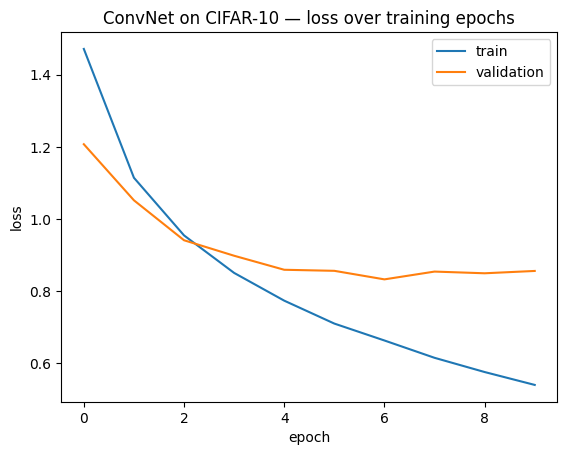

In [5]:
# The learning curves
plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.ylabel('loss'); plt.xlabel('epoch'); plt.legend()
plt.title('ConvNet on CIFAR-10 — loss over training epochs')
plt.show()

---

# Fixing the Overfit: The Day 2 Toolbox, Applied

The learning curves above told a clear story: training loss falls while validation loss climbs —
textbook **overfitting**. Yesterday we built a whole toolbox for exactly this situation. Let's apply
two of its tools to our CNN:

- **Data augmentation**: random crops and horizontal flips of the training images (a flipped cat is
  still a cat — note this *is* safe for CIFAR-10, unlike rotating MNIST digits!)
- **Dropout**: in the fully-connected head, where most of the parameters live

We'll also upgrade `train_model` to accept *any* model as an argument, so one function serves every
architecture we try.

In [7]:
# Augmentation is applied ONLY to the training set
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # pad then crop to 32x32
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                 download=True, transform=train_transform)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


In [8]:
# Same architecture as before, plus dropout in the fully-connected head
class ConvNetV2(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64*4*4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# train_model, generalised: the model is now an argument instead of being hard-coded inside
def train_model_v2(model, train_dataset, val_dataset, num_epochs, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = dict(train=[], val=[])

    for epoch in range(num_epochs):
        model.train()
        ts = time.time()
        train_losses = []
        for images, labels in train_dataset:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_dataset:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch: {epoch}  train loss: {history['train'][-1]:.4f}  "
              f"val loss: {history['val'][-1]:.4f}  time: {time.time()-ts:.1f}s")

    return model.eval(), history

Epoch: 0  train loss: 1.6329  val loss: 1.3074  time: 17.9s
Epoch: 1  train loss: 1.3261  val loss: 1.1324  time: 17.8s
Epoch: 2  train loss: 1.1848  val loss: 1.0196  time: 17.9s
Epoch: 3  train loss: 1.0860  val loss: 0.9420  time: 17.7s
Epoch: 4  train loss: 1.0340  val loss: 0.9333  time: 18.3s
Epoch: 5  train loss: 0.9796  val loss: 0.8663  time: 17.3s
Epoch: 6  train loss: 0.9446  val loss: 0.8293  time: 17.6s
Epoch: 7  train loss: 0.9198  val loss: 0.8111  time: 18.5s
Epoch: 8  train loss: 0.8960  val loss: 0.7861  time: 18.4s
Epoch: 9  train loss: 0.8697  val loss: 0.7979  time: 17.6s


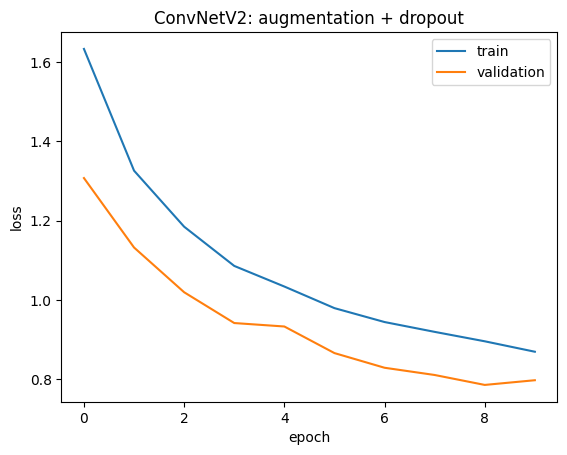

In [11]:
model_v2, history_v2 = train_model_v2(ConvNetV2(), train_loader_aug, test_loader, num_epochs=10)

plt.plot(history_v2['train'], label='train')
plt.plot(history_v2['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('ConvNetV2: augmentation + dropout')
plt.show()

In [12]:
# Test accuracy of the regularised model — our baseline to compare transfer learning against later.
print(f'Test accuracy of ConvNetV2 (augmentation + dropout): {accuracy(model_v2, test_loader):.1f}%')

Test accuracy of ConvNetV2 (augmentation + dropout): 72.4%


Compare this curve with the first one: the train/validation gap should be far smaller — the toolbox
works. (Train it for more epochs and the augmented model usually ends up *much better* on validation too,
because it can train longer before overfitting.)

---

# Seeing What the Network Sees: Feature Maps

A CNN isn't a black box — we can look at the **feature maps**: the output of a convolutional layer
for a given image. Each of the 32 maps from `conv1` shows where in the image *that filter's* pattern
was found. 

Early layers typically light up for edges and colours; deeper layers respond to textures
and object parts.

Feature maps shape: torch.Size([1, 32, 30, 30])


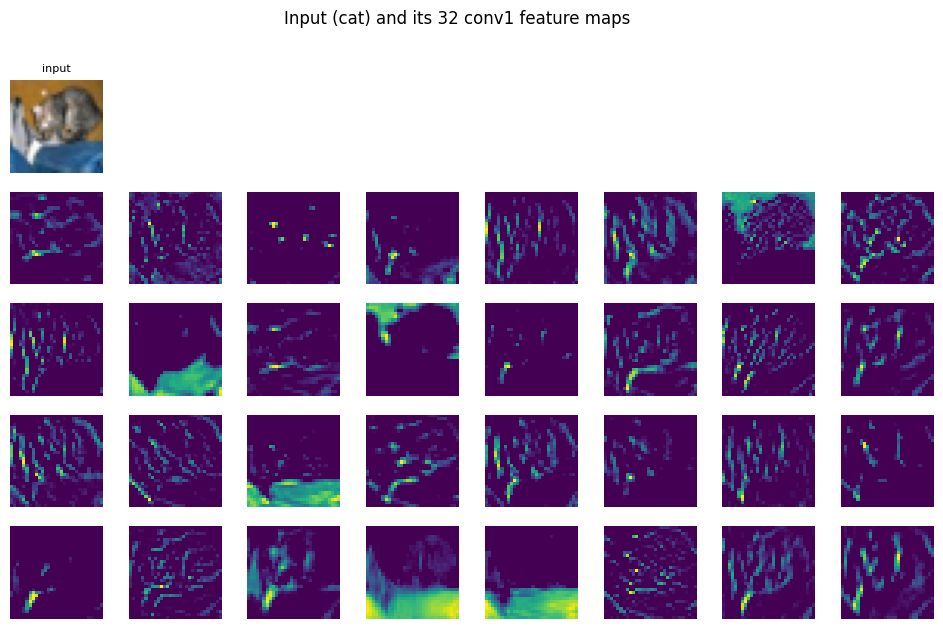

In [13]:
# Pass one test image through conv1 and look at all 32 resulting feature maps
images, labels = next(iter(test_loader))
img = images[0:1].to(device)

model_v2.eval()
with torch.no_grad():
    feature_maps = F.relu(model_v2.conv1(img))    # shape: (1, 32, 30, 30)

print('Feature maps shape:', feature_maps.shape)

fig = plt.figure(figsize=(12, 7))

# the input image — drawn directly on the subplot
ax = fig.add_subplot(5, 8, 1)
ax.imshow(np.transpose((images[0] / 2 + 0.5).numpy(), (1, 2, 0)))   # un-normalise to [0, 1]
ax.set_title('input', fontsize=8)
ax.axis('off')

# the 32 feature maps
for i in range(32):
    ax = fig.add_subplot(5, 8, i + 9)
    ax.imshow(feature_maps[0, i].cpu(), cmap='viridis')
    ax.axis('off')

plt.suptitle(f'Input ({classes[labels[0]]}) and its 32 conv1 feature maps')
plt.show()

---

# Transfer Learning: Standing on the Shoulders of Giants

Nobody trains large vision models from scratch on small datasets. Models like **ResNet**, trained on
ImageNet (1.2 million images, 1000 classes), have already learned a rich library of visual features —
edges, textures, shapes, object parts. **Transfer learning** reuses them:

1. Load a pretrained network
2. **Freeze** its convolutional layers (keep the learned features)
3. Replace the final classification layer with one for *your* classes
4. Train only that new layer (or later, *fine-tune* everything with a small learning rate)

The payoff is reaching strong accuracy with a *fraction* of the data and compute — and, once you
**fine-tune** (step 4), often surpassing a model trained from scratch.

### What is ResNet, and what exactly are we freezing?

You don't need to know ResNet's internals to *use* it, but it helps to picture its shape. **ResNet18** — like most image models — has two parts:

- a **backbone** (feature extractor): a stack of convolutional blocks — in ResNet these are `conv1` plus four stages `layer1`–`layer4` — that turn an image into a compact **512-number summary** of what's in it. This is where all the valuable ImageNet knowledge lives.
- a **head** (classifier): a single fully-connected layer named **`fc`** that maps those 512 numbers to class scores — 1000 of them, one per ImageNet class.

**Transfer learning** keeps the backbone and swaps the head:

1. **Freeze the backbone** (`requires_grad = False`) so its learned features stay put.
2. **Replace `fc`** with a fresh `Linear(512 → 10)` for our 10 CIFAR classes.
3. **Train only that new head.**

The print-outs below make this concrete — notice we end up training only a few thousand parameters out of ~11 million.

In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# --- SEE what ResNet18 is made of, before we touch it ---
print('ResNet18, top-level blocks:')
for name, module in resnet.named_children():
    print(f'  {name:9s} {module.__class__.__name__}')
print('\nThe "backbone" (feature extractor) is everything except `fc`.')
print('The "head" (classifier) is just:  resnet.fc =', resnet.fc)   # Linear(512 -> 1000 classes)
total = sum(p.numel() for p in resnet.parameters())
print(f'Total parameters: {total:,}')

# 1. freeze every pretrained layer (backbone keeps its ImageNet features)
for param in resnet.parameters():
    param.requires_grad = False

# 2. replace the final layer with a fresh one for OUR 10 classes (these params ARE trainable)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'\nAfter freezing + swapping the head: training only {trainable:,} of {total:,} '
      f'parameters ({100*trainable/total:.2f}%) — just the new head.')

ResNet18, top-level blocks:
  conv1     Conv2d
  bn1       BatchNorm2d
  relu      ReLU
  maxpool   MaxPool2d
  layer1    Sequential
  layer2    Sequential
  layer3    Sequential
  layer4    Sequential
  avgpool   AdaptiveAvgPool2d
  fc        Linear

The "backbone" (feature extractor) is everything except `fc`.
The "head" (classifier) is just:  resnet.fc = Linear(in_features=512, out_features=1000, bias=True)
Total parameters: 11,689,512

After freezing + swapping the head: training only 5,130 of 11,689,512 parameters (0.04%) — just the new head.


The cell below downloads
ResNet18 weights (~45 MB) the first time you run it; to keep the demo fast we **freeze the backbone
and train only the new final layer, for a single epoch on just 5,000 images**.

In [20]:
from torchvision import models
from torch.utils.data import Subset

# ResNet was trained on 224x224 ImageNet images, so we resize CIFAR images up
resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

resnet_train = Subset(torchvision.datasets.CIFAR10(root='./data', train=True, transform=resnet_transform),
                      range(0, 5000))
resnet_val   = Subset(torchvision.datasets.CIFAR10(root='./data', train=False, transform=resnet_transform),
                      range(0, 1000))
resnet_train_loader = torch.utils.data.DataLoader(resnet_train, batch_size=32, shuffle=True)
resnet_val_loader   = torch.utils.data.DataLoader(resnet_val, batch_size=32, shuffle=False)

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 1. freeze every pretrained layer
for param in resnet.parameters():
    param.requires_grad = False

# 2. replace the final layer (this new layer's parameters ARE trainable)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet, resnet_history = train_model_v2(resnet, resnet_train_loader, resnet_val_loader,
                                           num_epochs=1, lr=0.001)

Epoch: 0  train loss: 1.4468  val loss: 1.0043  time: 14.5s


In [21]:
# Accuracy of the transfer-learned model on the validation subset
n_correct, n_samples = 0, 0
resnet.eval()
with torch.no_grad():
    for images, labels in resnet_val_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = torch.max(resnet(images), 1)
        n_correct += (predicted == labels).sum().item()
        n_samples += labels.size(0)
print(f'ResNet18 transfer learning: {100*n_correct/n_samples:.1f}% accuracy '
      f'after 1 epoch on 5,000 images')

ResNet18 transfer learning: 69.1% accuracy after 1 epoch on 5,000 images


One epoch, 5,000 images, only the final layer trained — and it already lands in the **same ballpark**
as the ConvNet we trained from scratch on all 50,000 images for 10 epochs (scroll back and compare the
accuracies). Getting *comparable* results from a tiny fraction of the data and compute is the whole
point of reused features — and from here you'd **fine-tune** (unfreeze the deeper layers and train a
little longer) to push *past* the from-scratch model. ResNet is even fighting a handicap here: CIFAR's
32×32 images are crudely upscaled to the 224×224 it expects, throwing away detail.

---

# Beyond Classification: Detection & Recognition

Everything so far answers *"what is in this image?"*. Modern CNN applications go further:

### Object Detection — *what* is in the image, and *where*?

Detectors output **bounding boxes + class labels** for every object in the scene.

- **Two-stage detectors** (e.g. **Faster R-CNN**): a CNN backbone proposes regions likely to contain
  objects, then a second stage classifies each region. Accurate, but slower.
- **One-stage detectors** (e.g. **YOLO** — "You Only Look Once", **SSD**): predict boxes and classes
  in a single pass over a grid. Fast enough for real-time video.

Both are "just" CNN backbones like the ones you built today, with extra prediction heads.

### Face Recognition — *who* is this?

Face recognition is usually **not** classification (you can't retrain a network for every new
employee!). Instead a CNN is trained to map a face to an **embedding** — a vector (e.g. 128 numbers)
where the distance between two embeddings reflects whether they're the same person:

1. **Detect** the face in the image (a small detector network, e.g. MTCNN)
2. **Embed** the cropped face with a CNN (e.g. FaceNet, trained with a *triplet loss*: pull
   same-person embeddings together, push different-person embeddings apart)
3. **Compare** to known embeddings — nearest neighbour under a distance threshold

The same embedding trick powers image search and one-shot learning generally.

The cell below is a sample of such models. It runs a *pretrained* Faster R-CNN on any photo you give it — try one of your
own (downloads ~160 MB of weights on first run).

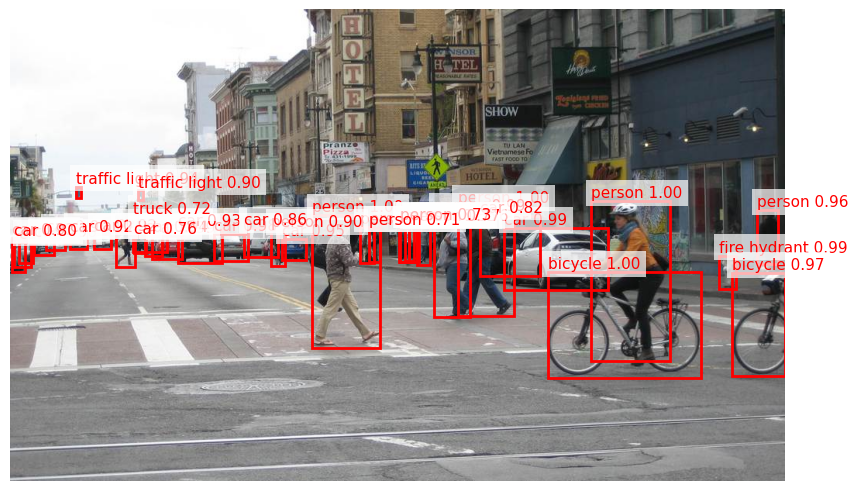

In [16]:
# OPTIONAL: object detection with a pretrained Faster R-CNN.
# Point IMAGE_PATH to any photo on your machine (street scenes work great), then re-run this cell.
import os
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from PIL import Image

IMAGE_PATH = 'my_photo.jpg'   # <-- change me to one of your own photos!

if not os.path.exists(IMAGE_PATH):
    print(f"No image found at '{IMAGE_PATH}'. Set IMAGE_PATH to one of your own photos and re-run "
          f"this cell to watch a pretrained detector find the objects in it.")
else:
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT   # downloads ~160 MB the first time
    detector = fasterrcnn_resnet50_fpn(weights=weights).eval()

    img = Image.open(IMAGE_PATH).convert('RGB')
    img_tensor = transforms.ToTensor()(img)

    with torch.no_grad():
        pred = detector([img_tensor])[0]

    # draw boxes for confident detections
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    labels_meta = weights.meta['categories']
    for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
        if score < 0.7:
            continue
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2))
        ax.text(x1, y1 - 5, f'{labels_meta[label]} {score:.2f}', color='red', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.axis('off')
    plt.show()

---

# Day 3 Recap & Exercises

**What you built today:** a CNN for colour images, learning curves that exposed its overfitting, an
overfitting-resistant ConvNetV2, feature-map visualisations, a transfer-learned ResNet, and a
working object detector.

> **Going deeper:** the `extras/convolution_output_dimensions_test.ipynb` notebook walks through
> convolution/pooling output sizes layer by layer — invaluable when your `nn.Linear` input size
> doesn't match and PyTorch yells at you.

### Exercises

1. **Architecture surgery.** Add a fourth conv layer (or widen the existing ones) in `ConvNetV2`.
   Recompute the flattened size (use the extras notebook!), retrain, and compare learning curves.
2. **Filter detective.** Visualize `conv2`'s feature maps for the same image. Are they more abstract
   than `conv1`'s?
3. **Per-class accuracy.** Compute accuracy separately for each of the 10 CIFAR classes. Which pairs
   get confused most, and can you guess why?
4. **Fine-tune deeper.** In the transfer-learning model, unfreeze `layer4` of the ResNet as well and
   train with a small LR (`1e-4`). Does it beat the frozen version?
5. **More epochs, or more data* In the transfer-learning model, run it for more epochs, and alternately, one epoch (or just less epochs than the other) but with more data. Which performs better?

### Tomorrow: Day 4

Images are 2D space. But the world is also full of **sequences** — speech, sensor readings, time
series, text — where what comes *next* depends on what came *before*. Tomorrow: recurrent networks
and LSTMs, built to model the fourth dimension.